# SATI-Q: tracheostomy timing and PICU outcomes

This notebook explores **SATI-Q data only**. The core admission-level source is `FIVARAPA_2015_2025.csv`; it distinguishes tracheostomy already present at PICU admission from one placed during the PICU stay. All summaries below are descriptive, not causal. Patient identifiers are not displayed.

**Primary exposure:** incident tracheostomy, with timing measured in days from `FECHAING` (PICU admission) to `TRAQFI` (placement date). **Outcomes:** hospital discharge status (`RESULTADOEGRESOH`, where “Fallece” is treated as hospital death) and PICU length of stay (`DIAS`). The dictionary describes `TRAQI` as status at PICU admission and `TRAQ` as use during the stay.

> Timing/outcome comparisons are especially vulnerable to confounding by severity and immortal-time bias: a patient must remain alive and in the PICU long enough to receive a later tracheostomy. These EDA plots cannot estimate treatment effects. Missing placement dates and outcomes are shown rather than silently imputed.

Admissions: 87,770
Tracheostomy groups:


,admissions
group,
No tracheostomy,82915
Present at admission,2392
Placed during PICU stay,2021
Unknown / inconsistent,442


Incident timing checks:


,n
incident cases,2021
missing placement date,80
negative timing,34
placement after PICU discharge,8
valid timing,1899


Missingness (%):


...

,admissions
RESTRAT,
0.0,1523
1.0,47963
10.0,577
11.0,33
12.0,1
2.0,14388
3.0,72
4.0,3531
5.0,4569


Incident outcomes by timing quartile (descriptive only):


,admissions,known_outcomes,hospital_deaths,median_los_days,hospital_death_% among known
timing_quartile,,,,,
"(-0.001, 9.0]",501,97,27,13.0,27.8
"(9.0, 19.0]",465,74,23,29.0,31.1
"(19.0, 30.0]",459,76,33,41.0,43.4
"(30.0, 427.0]",474,104,59,70.5,56.7


Reported use by year:


,admissions,tracheostomies,tracheostomy_%
year,,,
2015.0,5095,299,5.9
2016.0,6581,366,5.6
2017.0,7264,356,4.9
2018.0,7803,399,5.1
2019.0,8148,476,5.8
2020.0,5151,327,6.3
2021.0,10088,408,4.0
2022.0,9879,432,4.4
2023.0,7967,482,6.0


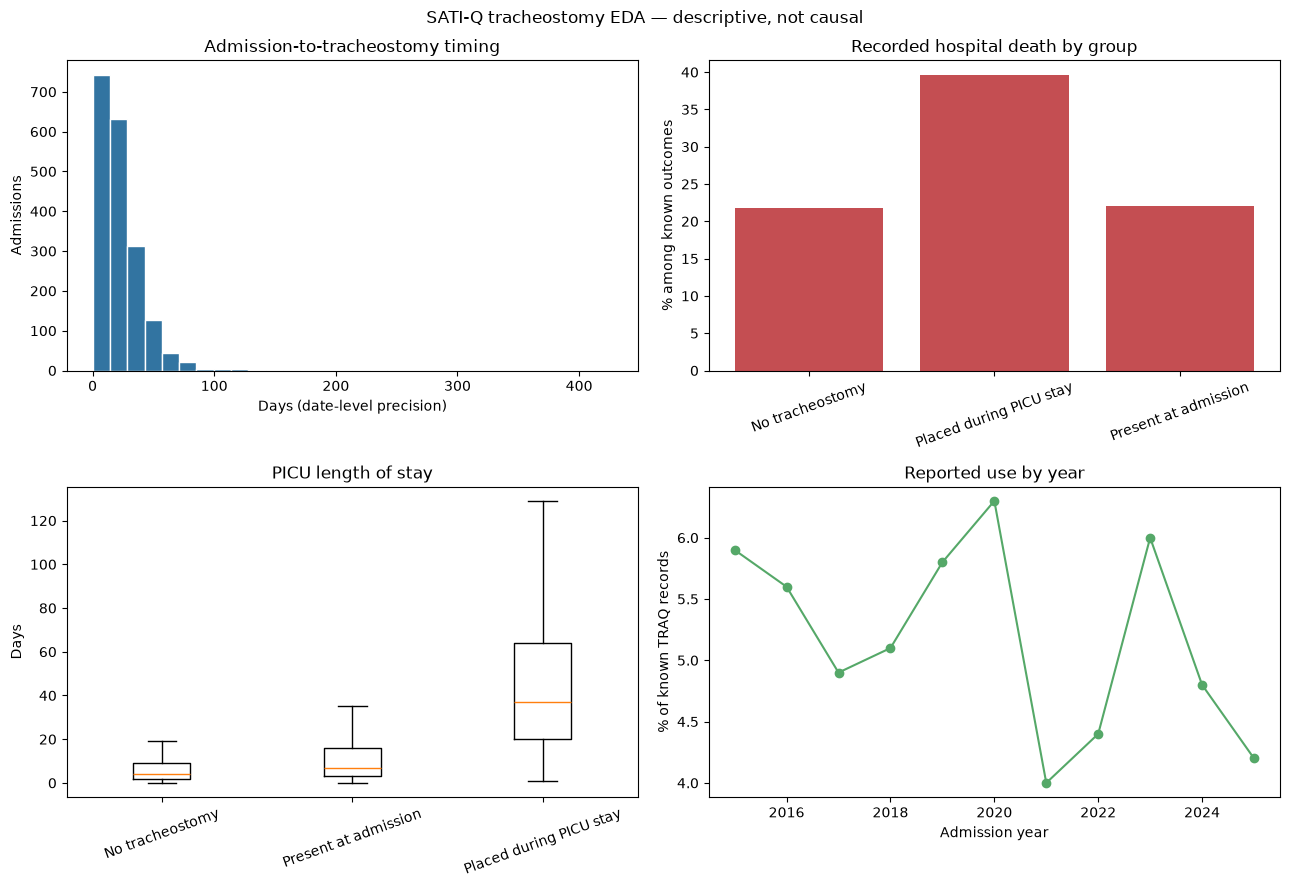

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Find SATI-Q relative to the workspace root or this notebook's directory.
roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
satiq_dir = next((p / "SATI-Q_WFPICCS_DATATHON_DATASET" for p in roots
                  if (p / "SATI-Q_WFPICCS_DATATHON_DATASET" / "FIVARAPA_2015_2025.csv").exists()), None)
if satiq_dir is None:
    raise FileNotFoundError("SATI-Q_WFPICCS_DATATHON_DATASET was not found relative to the working directory.")
df = pd.read_csv(satiq_dir / "FIVARAPA_2015_2025.csv", low_memory=False, dtype={"DNI": "string"})
for col in ["FECING", "FECHAING", "FECEGR", "TRAQFI", "TRAQFF", "FECINGH", "FECEGRH"]:
    if col in df:
        df[col] = pd.to_datetime(df[col], format="%d/%m/%Y", errors="coerce")
for col in ["TRAQ", "TRAQI", "TRAQE", "SEXO", "RESULTADOEGRESOH", "RESTRAT"]:
    if col in df:
        df[col] = df[col].astype("string").str.strip()
df["DIAS"] = pd.to_numeric(df["DIAS"], errors="coerce")

# RESULTADOEGRESOH is hospital discharge status; "Fallece" is recorded hospital death.
outcome = df["RESULTADOEGRESOH"].fillna("").str.casefold().str.strip()
df["hospital_death"] = outcome.eq("fallece").astype("boolean")
df.loc[outcome.eq(""), "hospital_death"] = pd.NA

# TIPO 0 = age in months, 1 = years, 2 = days; normalize age to years.
tipo = pd.to_numeric(df["TIPO"], errors="coerce")
age = pd.to_numeric(df["EDAD"], errors="coerce")
df["age_years"] = np.select([tipo.eq(0), tipo.eq(1), tipo.eq(2)], [age / 12, age, age / 365.25], default=np.nan)

# TRAQI separates tracheostomy present at admission from one placed during the stay.
trach, traqi = df["TRAQ"].str.upper(), df["TRAQI"].str.upper()
df["trach_group"] = np.select(
    [trach.eq("N").fillna(False).to_numpy(dtype=bool),
     (trach.eq("S").fillna(False) & traqi.eq("S").fillna(False)).to_numpy(dtype=bool),
     (trach.eq("S").fillna(False) & traqi.eq("N").fillna(False)).to_numpy(dtype=bool)],
    ["No tracheostomy", "Present at admission", "Placed during PICU stay"],
    default="Unknown / inconsistent")
incident = df.loc[df["trach_group"].eq("Placed during PICU stay")].copy()
incident["days_to_trach"] = (incident["TRAQFI"] - incident["FECHAING"]).dt.days
incident["after_discharge"] = (incident["TRAQFI"].notna() & incident["FECEGR"].notna() & (incident["TRAQFI"] > incident["FECEGR"]))
valid_timing = incident.loc[incident["days_to_trach"].ge(0) & incident["days_to_trach"].notna() & ~incident["after_discharge"]].copy()

print(f"Admissions: {len(df):,}")
print("Tracheostomy groups:")
display(df["trach_group"].value_counts().rename_axis("group").to_frame("admissions"))
print("Incident timing checks:")
display(pd.Series({"incident cases": len(incident), "missing placement date": incident["TRAQFI"].isna().sum(),
                   "negative timing": incident["days_to_trach"].lt(0).sum(),
                   "placement after PICU discharge": incident["after_discharge"].sum(),
                   "valid timing": len(valid_timing)}).to_frame("n"))

# Aggregate data-quality checks only; no patient-level records or identifiers are displayed.
fields = ["FECHAING", "FECEGR", "DIAS", "EDAD", "SEXO", "TRAQ", "TRAQI", "TRAQFI", "RESULTADOEGRESOH"]
print("Missingness (%):")
display((100 * df[fields].isna().mean()).round(1).rename("missing_%").to_frame())
if {"DNI", "FECING"}.issubset(df.columns):
    print(f"Rows in duplicate DNI + FECING keys: {df.duplicated(['DNI', 'FECING'], keep=False).sum():,}")

summary = df.groupby("trach_group", observed=False).agg(
    admissions=("trach_group", "size"), known_death_outcome=("hospital_death", "count"),
    hospital_deaths=("hospital_death", "sum"), median_los_days=("DIAS", "median"),
    median_age_years=("age_years", "median"))
summary["hospital_death_% among known"] = (100 * summary["hospital_deaths"] /
    summary["known_death_outcome"].replace(0, np.nan)).round(1)
print("Aggregate summaries by tracheostomy group:")
display(summary)
print("Sex distribution by group (%):")
display((pd.crosstab(df["trach_group"], df["SEXO"], normalize="index") * 100).round(1))
print("Hospital-discharge outcome categories:")
display(df["RESULTADOEGRESOH"].value_counts(dropna=False).head(15).to_frame("admissions"))
print("Raw RESTRAT codes (consult the dictionary before interpreting):")
display(df["RESTRAT"].value_counts(dropna=False).sort_index().to_frame("admissions"))

if len(valid_timing):
    valid_timing["timing_quartile"] = pd.qcut(valid_timing["days_to_trach"], 4, duplicates="drop")
    timing_summary = valid_timing.groupby("timing_quartile", observed=True).agg(
        admissions=("DNI", "size"), known_outcomes=("hospital_death", "count"),
        hospital_deaths=("hospital_death", "sum"), median_los_days=("DIAS", "median"))
    timing_summary["hospital_death_% among known"] = (100 * timing_summary["hospital_deaths"] /
        timing_summary["known_outcomes"].replace(0, np.nan)).round(1)
    print("Incident outcomes by timing quartile (descriptive only):")
    display(timing_summary)

# Annual reported use includes prevalent and incident cases; unknown TRAQ codes are excluded.
yearly = df.loc[trach.isin(["S", "N"])].copy()
yearly["year"] = yearly["FECHAING"].dt.year
yearly["used"] = trach.loc[yearly.index].eq("S").astype(int)
yearly_summary = yearly.groupby("year").agg(admissions=("used", "size"), tracheostomies=("used", "sum"))
yearly_summary["tracheostomy_%"] = (100 * yearly_summary["tracheostomies"] / yearly_summary["admissions"]).round(1)
print("Reported use by year:")
display(yearly_summary)

# Aggregate plots only; omit the unknown group from the mortality comparison.
groups = ["No tracheostomy", "Present at admission", "Placed during PICU stay"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
if len(valid_timing):
    axes[0, 0].hist(valid_timing["days_to_trach"], bins=30, color="#3274a1", edgecolor="white")
    axes[0, 0].set(title="Admission-to-tracheostomy timing", xlabel="Days (date-level precision)", ylabel="Admissions")
else:
    axes[0, 0].set_title("No valid incident timing dates")
plot_summary = summary.loc[summary.index.isin(groups) & summary["known_death_outcome"].gt(0)]
axes[0, 1].bar(plot_summary.index, plot_summary["hospital_death_% among known"], color="#c44e52")
axes[0, 1].set(title="Recorded hospital death by group", ylabel="% among known outcomes")
axes[0, 1].tick_params(axis="x", rotation=20)
los_groups = [g for g in groups if df.loc[df["trach_group"].eq(g), "DIAS"].notna().any()]
if los_groups:
    los_data = [df.loc[df["trach_group"].eq(g), "DIAS"].dropna() for g in los_groups]
    axes[1, 0].boxplot(los_data, tick_labels=los_groups, showfliers=False)
    axes[1, 0].set(title="PICU length of stay", ylabel="Days")
    axes[1, 0].tick_params(axis="x", rotation=20)
if not yearly_summary.empty:
    axes[1, 1].plot(yearly_summary.index, yearly_summary["tracheostomy_%"], marker="o", color="#55a868")
    axes[1, 1].set(title="Reported use by year", xlabel="Admission year", ylabel="% of known TRAQ records")
fig.suptitle("SATI-Q tracheostomy EDA — descriptive, not causal")
fig.tight_layout()
plt.show()